In [10]:
# task3_kmp.py
# CSCI 4407 - Assignment 3
# Task 3: Knuth-Morris-Pratt (KMP) string matching
#
# This program:
# - accepts a binary text sequence and a binary pattern
# - computes the LPS (Longest Prefix Suffix) table
# - finds all occurrences of the pattern in the text
# - prints the match positions and total number of matches

def LPS(pattern):
    
    """
    Build the LPS (Longest Prefix Suffix) table for the pattern.
    lps[i] stores the length of the longest proper prefix of pattern[0:i+1]
    that is also a suffix of pattern[0:i+1].
    """
    m = len(pattern)
    lps = [0] * m

    j = 0   # length of previous longest prefix suffix
    i = 1   # current position in pattern

    while i < m:
        if pattern[i] == pattern[j]:
            j += 1
            lps[i] = j
            i += 1
        else:
            if j != 0:
                j = lps[j - 1]
            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_search(text, pattern):

    """
    Perform KMP pattern matching.
    Returns a list of all starting positions where pattern appears in text.
    """
    if len(pattern) == 0:
        return []

    lps = LPS(pattern)
    matches = []

    i = 0  # index for text
    j = 0  # index for pattern

    while i < len(text):
        if text[i] == pattern[j]:
            i += 1
            j += 1

        if j == len(pattern):
            matches.append(i - j)
            j = lps[j - 1]

        elif i < len(text) and text[i] != pattern[j]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches


def is_binary_string(s):
    """
    Return True if the string contains only 0 and 1 characters.
    """
    return all(ch in '01' for ch in s)


def main():
    print("Knuth-Morris-Pratt (KMP) Pattern Matching")
    print("-" * 40)

    # Example from Task 2
    default_pattern = "101101"
    default_text = "10110100101101101101"

    use_example = input("Use built-in example? (y/n): ").strip().lower()

    if use_example == 'y':
        text = default_text
        pattern = default_pattern
    else:
        text = input("Enter binary text sequence: ").strip()
        pattern = input("Enter binary pattern: ").strip()

    # Input validation
    if not text:
        print("Error: text cannot be empty.")
        return

    if not pattern:
        print("Error: pattern cannot be empty.")
        return

    if not is_binary_string(text):
        print("Error: text must contain only 0 and 1.")
        return

    if not is_binary_string(pattern):
        print("Error: pattern must contain only 0 and 1.")
        return

    # Compute results
    lps = LPS(pattern)
    matches = kmp_search(text, pattern)

    # Output
    print("\nText:    ", text)
    print("Pattern: ", pattern)
    print("LPS:     ", lps)

    if matches:
        print("Match positions:", matches)
        print("Total matches:", len(matches))
    else:
        print("Match positions: []")
        print("Total matches: 0")


if __name__ == "__main__":
    main()

Knuth-Morris-Pratt (KMP) Pattern Matching
----------------------------------------

Text:     10110100101101101101
Pattern:  101101
LPS:      [0, 0, 1, 1, 2, 3]
Match positions: [0, 8, 11, 14]
Total matches: 4


In [6]:
# task4_generate_sequences.py
# CSCI 4407 - Assignment 3
# Task 4: Simulation of Cryptographic Scenarios

import random

SEQUENCE_LENGTH = 1_000_000


def generate_case_a_random(n):
    """
    Case A:
    Generate a pseudorandom binary sequence of length n.
    """
    return ''.join(random.choice('01') for _ in range(n))


def generate_case_b_weak(n):
    """
    Case B:
    Generate a weak sequence by repeating a fixed block.
    This creates obvious structure and periodic repetition.
    """
    block = "10110011"
    repeats_needed = (n // len(block)) + 1
    sequence = (block * repeats_needed)[:n]
    return sequence


def generate_case_c_modified(case_a, interval=50):
    """
    Case C:
    Start from Case A and flip one bit every fixed interval.
    This introduces controlled structural changes.
    """
    seq_list = list(case_a)

    for i in range(0, len(seq_list), interval):
        seq_list[i] = '1' if seq_list[i] == '0' else '0'

    return ''.join(seq_list)


def save_sequence(filename, sequence):
    """
    Save a sequence to a text file.
    """
    with open(filename, 'w') as f:
        f.write(sequence)


def print_sample(label, sequence, sample_size=100):
    """
    Print a short sample from the beginning of the sequence.
    """
    print(f"{label} length: {len(sequence)}")
    print(f"{label} sample (first {sample_size} bits):")
    print(sequence[:sample_size])
    print()


def main():
    print("Generating sequences for Task 4...\n")

    # Case A
    case_a = generate_case_a_random(SEQUENCE_LENGTH)
    print_sample("Case A", case_a)

    # Case B
    case_b = generate_case_b_weak(SEQUENCE_LENGTH)
    print_sample("Case B", case_b)

    # Case C
    case_c = generate_case_c_modified(case_a, interval=50)
    print_sample("Case C", case_c)

    # Save sequences for later use in Task 5
    save_sequence("case_a_random.txt", case_a)
    save_sequence("case_b_weak.txt", case_b)
    save_sequence("case_c_modified.txt", case_c)

    print("Sequences saved to:")
    print(" - case_a_random.txt")
    print(" - case_b_weak.txt")
    print(" - case_c_modified.txt")


if __name__ == "__main__":
    main()

Generating sequences for Task 4...

Case A length: 1000000
Case A sample (first 100 bits):
0101000110111011010101001111111111010011110011101011011010111001001001000010001001100010101011111010

Case B length: 1000000
Case B sample (first 100 bits):
1011001110110011101100111011001110110011101100111011001110110011101100111011001110110011101100111011

Case C length: 1000000
Case C sample (first 100 bits):
1101000110111011010101001111111111010011110011101001011010111001001001000010001001100010101011111010

Sequences saved to:
 - case_a_random.txt
 - case_b_weak.txt
 - case_c_modified.txt


In [11]:
# task5_pattern_detection.py
# CSCI 4407 - Assignment 3
# Task 5: Pattern Detection and Experimental Analysis

def LPS(pattern):
    m = len(pattern)
    lps = [0] * m
    j = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[j]:
            j += 1
            lps[i] = j
            i += 1
        else:
            if j != 0:
                j = lps[j - 1]
            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_search(text, pattern):
    if len(pattern) == 0:
        return []

    lps = LPS(pattern)
    matches = []

    i = 0
    j = 0

    while i < len(text):
        if text[i] == pattern[j]:
            i += 1
            j += 1

        if j == len(pattern):
            matches.append(i - j)
            j = lps[j - 1]

        elif i < len(text) and text[i] != pattern[j]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches


def load_sequence(filename):
    with open(filename, "r") as f:
        return f.read().strip()


def analyze_case(case_name, sequence, patterns, max_positions_to_show=20):
    print("=" * 70)
    print(f"{case_name}")
    print("=" * 70)

    results = {}

    for label, pattern in patterns.items():
        matches = kmp_search(sequence, pattern)
        results[label] = {
            "pattern": pattern,
            "count": len(matches),
            "positions": matches
        }

        print(f"\nPattern length: {label}")
        print(f"Pattern: {pattern}")
        print(f"Total matches: {len(matches)}")

        if matches:
            print(f"First {min(max_positions_to_show, len(matches))} positions: {matches[:max_positions_to_show]}")
        else:
            print("Positions: []")

    return results


def main():
    # Load sequences generated in Task 4
    case_a = load_sequence("case_a_random.txt")
    case_b = load_sequence("case_b_weak.txt")
    case_c = load_sequence("case_c_modified.txt")

    # Patterns of length 8, 16, and 32
    patterns = {
        "8 bits":  "10110011",
        "16 bits": "1011001110110011",
        "32 bits": "10110011101100111011001110110011"
    }

    print("\nStarting Task 5 pattern detection...\n")

    results_a = analyze_case("Case A - Random Sequence", case_a, patterns)
    results_b = analyze_case("Case B - Weak Sequence", case_b, patterns)
    results_c = analyze_case("Case C - Modified Sequence", case_c, patterns)

    print("\n" + "=" * 70)
    print("SUMMARY TABLE")
    print("=" * 70)
    print(f"{'Pattern Length':<15}{'Case A':<15}{'Case B':<15}{'Case C':<15}")

    for label in patterns:
        count_a = results_a[label]["count"]
        count_b = results_b[label]["count"]
        count_c = results_c[label]["count"]
        print(f"{label:<15}{count_a:<15}{count_b:<15}{count_c:<15}")


if __name__ == "__main__":
    main()


Starting Task 5 pattern detection...

Case A - Random Sequence

Pattern length: 8 bits
Pattern: 10110011
Total matches: 3996
First 20 positions: [298, 619, 895, 1720, 2334, 2477, 2616, 2665, 3652, 4159, 4213, 4221, 4619, 5278, 5303, 6529, 6667, 6696, 6827, 7016]

Pattern length: 16 bits
Pattern: 1011001110110011
Total matches: 31
First 20 positions: [4213, 17164, 30435, 30443, 73791, 170231, 327698, 338119, 362535, 367217, 369411, 394962, 414383, 458055, 492361, 607727, 719756, 720769, 737642, 762668]

Pattern length: 32 bits
Pattern: 10110011101100111011001110110011
Total matches: 0
Positions: []
Case B - Weak Sequence

Pattern length: 8 bits
Pattern: 10110011
Total matches: 125000
First 20 positions: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152]

Pattern length: 16 bits
Pattern: 1011001110110011
Total matches: 124999
First 20 positions: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152]

Pattern length: 32 bi

TASK 6: OBSERVED VS EXPECTED FREQUENCY
Pattern   Expected       Case A      Case B      Case C      
8 bits    3906.250000    3996        125000      3601        
16 bits   15.258789      31          124999      26          
32 bits   0.000233       0           124997      0           


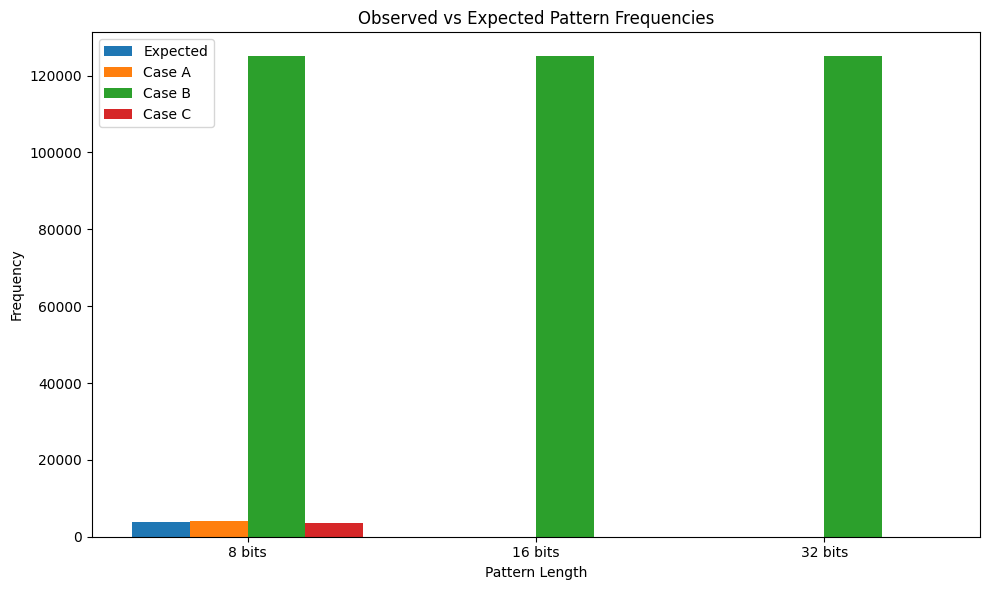

In [7]:
# task6_statistical_analysis.py
# CSCI 4407 - Assignment 3
# Task 6: Statistical Evaluation of Results

import math
import matplotlib.pyplot as plt

N = 1_000_000

# Replace these sample values with your real Task 5 results
observed = {
    "8 bits":  {"length": 8,  "A": 3996,   "B": 125000, "C": 3601},
    "16 bits": {"length": 16, "A": 31,     "B": 124999,  "C": 26},
    "32 bits": {"length": 32, "A": 0,      "B": 124997,  "C": 0}
}

def expected_frequency(n, pattern_length):
    return n / (2 ** pattern_length)

print("=" * 72)
print("TASK 6: OBSERVED VS EXPECTED FREQUENCY")
print("=" * 72)
print(f"{'Pattern':<10}{'Expected':<15}{'Case A':<12}{'Case B':<12}{'Case C':<12}")

labels = []
expected_vals = []
case_a_vals = []
case_b_vals = []
case_c_vals = []

for label, data in observed.items():
    exp = expected_frequency(N, data["length"])
    a = data["A"]
    b = data["B"]
    c = data["C"]

    labels.append(label)
    expected_vals.append(exp)
    case_a_vals.append(a)
    case_b_vals.append(b)
    case_c_vals.append(c)

    print(f"{label:<10}{exp:<15.6f}{a:<12}{b:<12}{c:<12}")

# Graph
x = range(len(labels))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar([i - 1.5 * width for i in x], expected_vals, width=width, label="Expected")
plt.bar([i - 0.5 * width for i in x], case_a_vals, width=width, label="Case A")
plt.bar([i + 0.5 * width for i in x], case_b_vals, width=width, label="Case B")
plt.bar([i + 1.5 * width for i in x], case_c_vals, width=width, label="Case C")

plt.xticks(list(x), labels)
plt.xlabel("Pattern Length")
plt.ylabel("Frequency")
plt.title("Observed vs Expected Pattern Frequencies")
plt.legend()
plt.tight_layout()
plt.savefig("task6_observed_vs_expected.png")
plt.show()

TASK 6: OBSERVED VS EXPECTED FREQUENCY ANALYSIS
Pattern   Expected       Case A      Dev A          Case B      Dev B          Case C      Dev C          
8 bits    3906.250000    3996        89.750000      125000      121093.750000  3901        5.250000       
16 bits   15.258789      31          15.741211      124999      124983.741211  26          10.741211      
32 bits   0.000233       0           0.000233       124997      124996.999767  0           0.000233       

Graph saved as: task6_observed_vs_expected.png


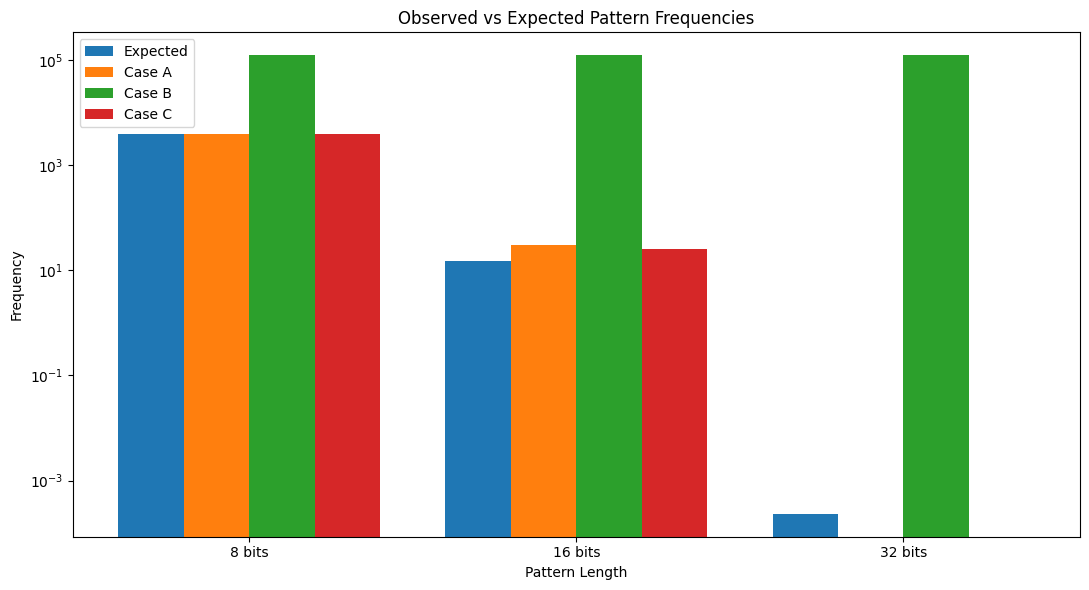

In [8]:
# task6_statistical_analysis.py
# CSCI 4407 - Assignment 3
# Task 6: Statistical Evaluation of Results
#
# This script:
# 1. stores the observed pattern counts from Task 5
# 2. computes the expected frequency using E(P) = N / 2^|P|
# 3. prints a comparison table
# 4. computes the deviation between observed and expected values
# 5. generates one graph showing Expected, Case A, Case B, and Case C
#
# Note:
# If you are using Jupyter and matplotlib still fails, run this file directly
# from the terminal while your virtual environment is activated:
#     python3 task6_statistical_analysis.py

import math
import matplotlib.pyplot as plt

# Total sequence length
N = 1_000_000

# Observed counts from your Task 5 output
observed = {
    "8 bits": {
        "length": 8,
        "A": 3996,
        "B": 125000,
        "C": 3901
    },
    "16 bits": {
        "length": 16,
        "A": 31,
        "B": 124999,
        "C": 26
    },
    "32 bits": {
        "length": 32,
        "A": 0,
        "B": 124997,
        "C": 0
    }
}


def expected_frequency(n, pattern_length):
    """
    Compute expected frequency using:
    E(P) = N / 2^|P|
    """
    return n / (2 ** pattern_length)


def absolute_deviation(observed_value, expected_value):
    """
    Return the absolute difference between observed and expected.
    """
    return abs(observed_value - expected_value)


def print_results_table():
    """
    Print a formatted table showing expected values, observed values,
    and deviations for each pattern length.
    """
    print("=" * 110)
    print("TASK 6: OBSERVED VS EXPECTED FREQUENCY ANALYSIS")
    print("=" * 110)
    print(
        f"{'Pattern':<10}"
        f"{'Expected':<15}"
        f"{'Case A':<12}"
        f"{'Dev A':<15}"
        f"{'Case B':<12}"
        f"{'Dev B':<15}"
        f"{'Case C':<12}"
        f"{'Dev C':<15}"
    )

    for label, data in observed.items():
        exp = expected_frequency(N, data["length"])

        a = data["A"]
        b = data["B"]
        c = data["C"]

        dev_a = absolute_deviation(a, exp)
        dev_b = absolute_deviation(b, exp)
        dev_c = absolute_deviation(c, exp)

        print(
            f"{label:<10}"
            f"{exp:<15.6f}"
            f"{a:<12}"
            f"{dev_a:<15.6f}"
            f"{b:<12}"
            f"{dev_b:<15.6f}"
            f"{c:<12}"
            f"{dev_c:<15.6f}"
        )


def create_graph():
    """
    Create one graph showing Expected, Case A, Case B, and Case C.
    A logarithmic y-scale is used because Case B is much larger than the others.
    """
    labels = []
    expected_vals = []
    case_a_vals = []
    case_b_vals = []
    case_c_vals = []

    for label, data in observed.items():
        labels.append(label)
        expected_vals.append(expected_frequency(N, data["length"]))
        case_a_vals.append(data["A"])
        case_b_vals.append(data["B"])
        case_c_vals.append(data["C"])

    x = range(len(labels))
    width = 0.2

    plt.figure(figsize=(11, 6))

    plt.bar([i - 1.5 * width for i in x], expected_vals, width=width, label="Expected")
    plt.bar([i - 0.5 * width for i in x], case_a_vals, width=width, label="Case A")
    plt.bar([i + 0.5 * width for i in x], case_b_vals, width=width, label="Case B")
    plt.bar([i + 1.5 * width for i in x], case_c_vals, width=width, label="Case C")

    plt.xticks(list(x), labels)
    plt.xlabel("Pattern Length")
    plt.ylabel("Frequency")
    plt.title("Observed vs Expected Pattern Frequencies")
    plt.yscale("log")  # helps make all bars visible due to very large Case B values
    plt.legend()
    plt.tight_layout()

    # Save graph to file
    plt.savefig("task6_observed_vs_expected.png", dpi=300)
    print("\nGraph saved as: task6_observed_vs_expected.png")

    # Show graph
    plt.show()


def main():
    print_results_table()
    create_graph()


if __name__ == "__main__":
    main()